# Import Necessary libs

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import plotly.express as px
from sklearn.feature_extraction.text import TfidfVectorizer,CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Embedding,GRU,LSTM,Bidirectional,SimpleRNN
from tensorflow.keras.utils import pad_sequences
from sklearn.preprocessing import LabelEncoder
from keras.models import Sequential
from keras.layers import Dense,Dropout
import tensorflow as tf
import warnings

warnings.filterwarnings('ignore')

# Loading our data

In [2]:
# https://github.com/rokibulroni/Phishing-Email-Dataset

df = pd.read_csv("./Phishing-Email-dataset-main/CEAS_08.csv", encoding="latin1")

df.head()

,sender,receiver,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,user4@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,user2.9@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,SpamAssassin Dev <xrh@spamassassin.apache.org>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,user2.2@gvc.ceas-challenge.cc,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1


# Text Preprocessing

In [3]:
df.isnull().sum()

sender        0
receiver    462
date          0
subject      28
body          0
label         0
urls          0
dtype: int64

In [4]:
# Our given dataset has null values in the receiver and subject categories. Since receiver is not very important in the context of 
# identifying phishing attempts, we will remove the receiver column. We will replace null subject values with a placeholder such as 0.

# Remove the receiver column
df = df.drop(columns=["receiver"], errors="ignore")

# Replace missing subject values with "0"
df["subject"] = df["subject"].fillna("0")

df.isnull().sum()

sender     0
date       0
subject    0
body       0
label      0
urls       0
dtype: int64

## Distribution of the data

In [5]:
print("Dimension of the row data:",df.shape)

Dimension of the row data: (39154, 6)


In [6]:
df.head(20)

,sender,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,"Buck up, your troubles caused by small dimensi...",1,1
1,Mok <ipline's1983@icable.ph>,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,\nUpgrade your sex and pleasures with these te...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
3,Michael Parker <ivqrnai@pobox.com>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,Would anyone object to removing .so from this ...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,\nWelcomeFastShippingCustomerSupport\nhttp://7...,1,1
5,Caroline Aragon <dwthaidomainnamesm@thaidomain...,"Wed, 06 Aug 2008 05:31:22 +0600",From Caroline Aragon,\n\n\n\n\nYo wu urS mo ou go rc ebo eForM rgi ...,1,0
6,Replica Watches <jhorton@thebakercompanies.com>,"Tue, 05 Aug 2008 21:44:01 +0000",Replica Watches,We have fake Swiss Men's and Ladie's Replica \...,1,0
7,Daily Top 10 <acidirev_1972@tcwpg.com>,"Tue, 05 Aug 2008 20:41:14 -0300",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1
8,qydlqcws-iacfym@issues.apache.org,"Tue, 05 Aug 2008 15:31:03 -0800",[Bug 5780] URI processing turns uuencoded stri...,http://issues.apache.org/SpamAssassin/show_bug...,0,1
9,Daily Top 10 <orn|dent_1973@musicaedischi.it>,"Wed, 06 Aug 2008 00:31:38 +0100",CNN.com Daily Top 10,>+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+=+...,1,1


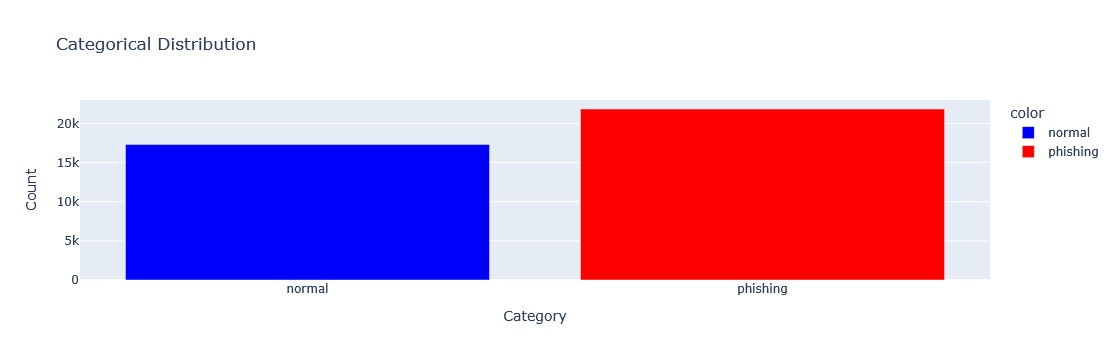

In [7]:
import plotly.express as px

# Get counts by label
counts = df['label'].value_counts().sort_index()  # sort so 0, then 1

# Map numeric labels to names
label_names = {0: 'normal', 1: 'phishing'}
categories = [label_names[i] for i in counts.index]

# Define colors matching categories
colors = ['blue' if label == 'normal' else 'red' for label in categories]

# Create bar chart
fig = px.bar(
    x=categories,
    y=counts.values,
    color=categories,
    color_discrete_map={'normal': 'blue', 'phishing': 'red'},
    labels={'x': 'Category', 'y': 'Count'},
    title="Categorical Distribution"
)

fig.show()


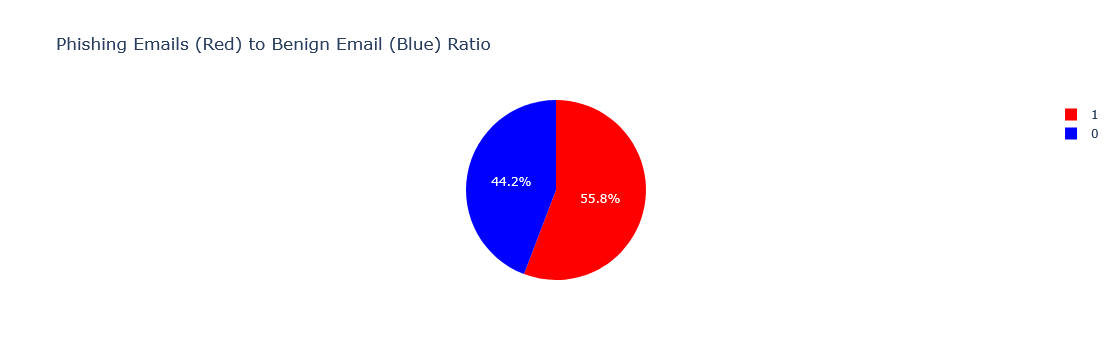

In [8]:
# Create the pie chart
fig_pie = px.pie(
    names=counts.index,
    values=counts.values,
    title="Phishing Emails (Red) to Benign Email (Blue) Ratio",
    color=counts.index,
    color_discrete_map={0: 'blue', 1: 'red'}
)

fig_pie.show()


# The ratio of normal to phishing is roughly around the 1:1 ratio that we are looking for, should be fine


## Integer Encoding

##  Remove hyperlinks, punctuations, extra space

In [9]:
import re

def preprocess_text(text):
    # Remove hyperlinks
    text = re.sub(r'http\S+', '', text)

    # Remove punctuations
    text = re.sub(r'[^\w\s]', '', text)

    # Convert to lowercase
    text = text.lower()

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["body"] = df["body"].astype(str)

# Apply the preprocess_text function to the specified column in the DataFrame
df["body"] = df["body"].apply(preprocess_text)

In [10]:
df.head()

,sender,date,subject,body,label,urls
0,Young Esposito <Young@iworld.de>,"Tue, 05 Aug 2008 16:31:02 -0700",Never agree to be a loser,buck up your troubles caused by small dimensio...,1,1
1,Mok <ipline's1983@icable.ph>,"Tue, 05 Aug 2008 18:31:03 -0500",Befriend Jenna Jameson,upgrade your sex and pleasures with these tech...,1,1
2,Daily Top 10 <Karmandeep-opengevl@universalnet...,"Tue, 05 Aug 2008 20:28:00 -1200",CNN.com Daily Top 10,the daily top 10 from cnncom top videos and st...,1,1
3,Michael Parker <ivqrnai@pobox.com>,"Tue, 05 Aug 2008 17:31:20 -0600",Re: svn commit: r619753 - in /spamassassin/tru...,would anyone object to removing so from this l...,0,1
4,Gretchen Suggs <externalsep1@loanofficertool.com>,"Tue, 05 Aug 2008 19:31:21 -0400",SpecialPricesPharmMoreinfo,welcomefastshippingcustomersupport,1,1


# WordCloud

## wordcloud of avaiable stopwords

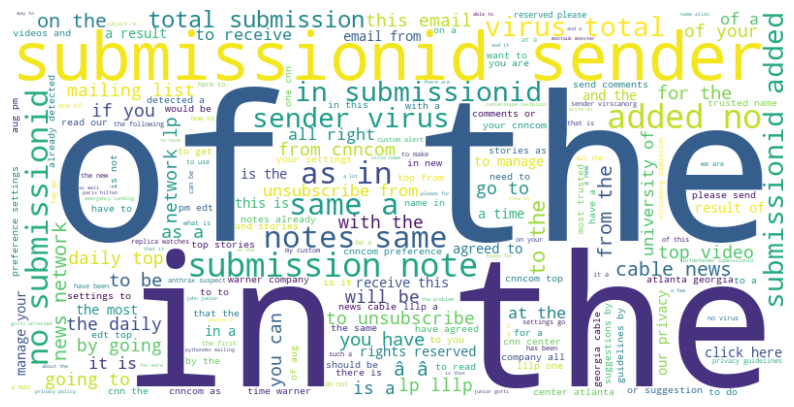

In [11]:
from wordcloud import WordCloud

#combine all rows into a single string
all_mails = " ".join(df["body"])

#create a wordcloud object
word_cloud = WordCloud(stopwords="english",width=800,height=400,background_color='white').generate(all_mails)

plt.figure(figsize=(10,6))
plt.imshow(word_cloud,interpolation='bilinear')
plt.axis("off")
plt.show()

## wordcloud of unique words

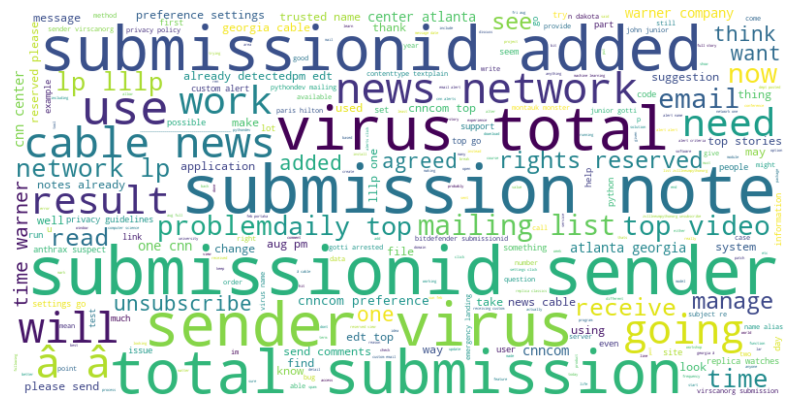

In [12]:
#combine all rows into a single string
all_mails = " ".join(df["body"])

#create a wordcloud object
word_cloud = WordCloud(width=800,height=400,background_color='white',max_words=10000).generate(all_mails)
plt.figure(figsize=(10,6))
plt.imshow(word_cloud,interpolation='bilinear')
plt.axis("off")
plt.show()

##  Converting text into vector

### Tfidf vectorizer and split into train/test

In [13]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Drop date (not needed)
df = df.drop(columns=['date'])

# Handle missing values
df['subject'] = df['subject'].fillna('')
df['body'] = df['body'].fillna('')

# Combine subject and body into one text column for vectorization
df['text_combined'] = df['subject'] + ' ' + df['body']

# Vectorize combined text
tf = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5
)
feature_x = tf.fit_transform(df['text_combined'])

# Encode label as int
le = LabelEncoder()
y_tf = le.fit_transform(df['label'])

# Split indices & labels (to keep track of original rows)
indices = df.index.to_numpy()
train_indices, test_indices, y_train, y_test = train_test_split(
    indices,
    y_tf,
    train_size=0.8,
    random_state=0,
    stratify=y_tf
)

# Slice feature matrix based on indices
x_train = feature_x[train_indices]
x_test = feature_x[test_indices]


# Applying different types of models


## Naive Bayes

In [14]:
#naive bayes works with condtional probability
from sklearn.naive_bayes import MultinomialNB
nb = MultinomialNB()
nb.fit(x_train,y_train)

MultinomialNB()

accuracy from native bayes: 96.97 %
f1 score from naive bayes: 97.22 %
classification report :

               precision    recall  f1-score   support

           0       0.94      1.00      0.97      3462
           1       1.00      0.95      0.97      4369

    accuracy                           0.97      7831
   macro avg       0.97      0.97      0.97      7831
weighted avg       0.97      0.97      0.97      7831



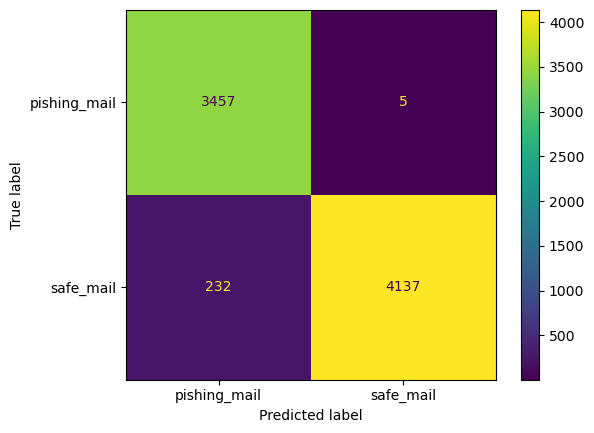

In [15]:
from sklearn.metrics import accuracy_score,f1_score,classification_report,ConfusionMatrixDisplay,confusion_matrix
pred_nav = nb.predict(x_test)

# Checking the performance

print(f"accuracy from native bayes: {accuracy_score(y_test,pred_nav)*100:.2f} %")
print(f"f1 score from naive bayes: {f1_score(y_test,pred_nav)*100:.2f} %")
print("classification report :\n\n",classification_report(y_test,pred_nav))

#confusion matrix
clf_nav = confusion_matrix(y_test,pred_nav)
cx_ = ConfusionMatrixDisplay(clf_nav,display_labels=['pishing_mail','safe_mail']).plot()
plt.show()

## Logistic Regression


accuracy from logistic regression:99.30 %
f1 score from logistic regression: 99.37 %
classification report : 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      3462
           1       0.99      1.00      0.99      4369

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99      0.99      0.99      7831



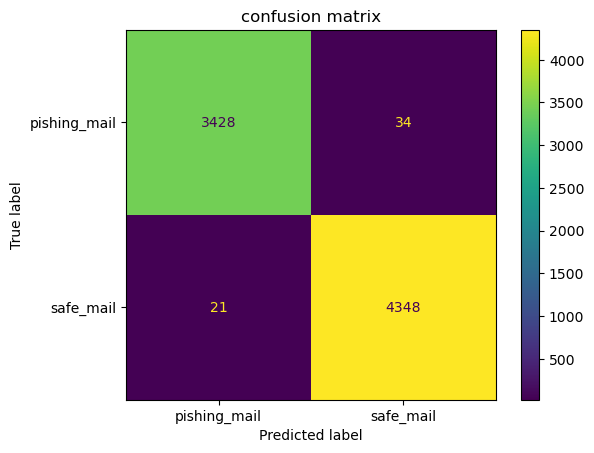

In [16]:
lg = LogisticRegression()
lg.fit(x_train,y_train)

# prediction
pred_lg = lg.predict(x_test)
# performance
print("")
print(f"accuracy from logistic regression:{accuracy_score(y_test,pred_lg)*100:.2f} %")
print(f"f1 score from logistic regression: {f1_score(y_test,pred_lg)*100:.2f} %")
print("classification report : \n",classification_report(y_test,pred_lg))

clf_lg = confusion_matrix(y_test,pred_lg)
cx_ = ConfusionMatrixDisplay(clf_lg,display_labels=['pishing_mail','safe_mail']).plot()
plt.title("confusion matrix")
plt.show()

In [17]:
# save the model for future use

import joblib

# Save the trained model to a file
joblib.dump(nb, 'email_spam_nb.pkl')

['email_spam_nb.pkl']

## SGD Classifier

accuracy from logistic regression:99.36 %
f1 score from logistic regression: 99.43 %
classification report : 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      3462
           1       0.99      1.00      0.99      4369

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99      0.99      0.99      7831



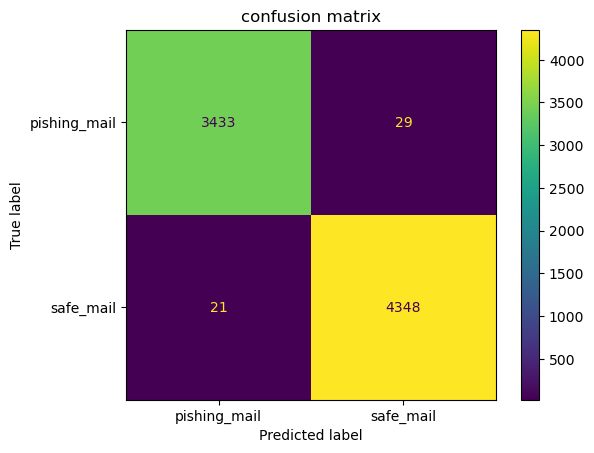

In [18]:
from sklearn.linear_model import SGDClassifier

# passing object
sgd = SGDClassifier()
sgd.fit(x_train,y_train)

# prediction
pred_sgd = sgd.predict(x_test)
# performance
print(f"accuracy from logistic regression:{accuracy_score(y_test,pred_sgd)*100:.2f} %")
print(f"f1 score from logistic regression: {f1_score(y_test,pred_sgd)*100:.2f} %")
print("classification report : \n",classification_report(y_test,pred_sgd))

clf_sgd = confusion_matrix(y_test,pred_sgd)
cx_ = ConfusionMatrixDisplay(clf_sgd,display_labels=['pishing_mail','safe_mail']).plot()
plt.title("confusion matrix")
plt.show()

## Decision Tree

accuracy from Decision Tree:98.76 %
f1 score from Decision Tree: 98.89 %
classification report : 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      3462
           1       0.99      0.99      0.99      4369

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99      0.99      0.99      7831



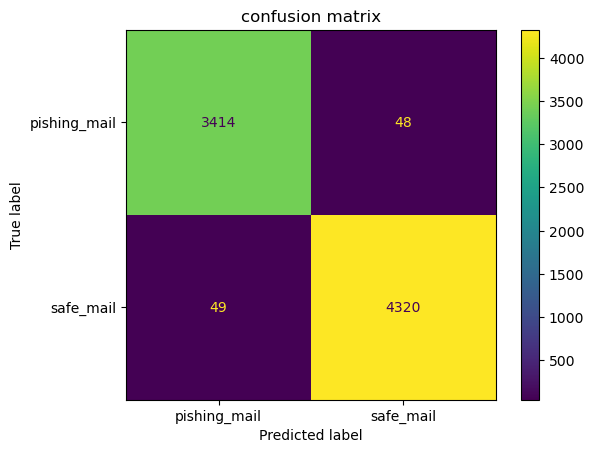

In [19]:
dtr = DecisionTreeClassifier() #passing object
dtr.fit(x_train,y_train)

#prediction
pred_dtr = dtr.predict(x_test)

#performance
print(f"accuracy from Decision Tree:{accuracy_score(y_test,pred_dtr)*100:.2f} %")
print(f"f1 score from Decision Tree: {f1_score(y_test,pred_dtr)*100:.2f} %")
print("classification report : \n",classification_report(y_test,pred_dtr))

#confusion matrix
clf_dtr = confusion_matrix(y_test,pred_dtr)
cx_ = ConfusionMatrixDisplay(clf_dtr,display_labels=['pishing_mail','safe_mail']).plot()
plt.title("confusion matrix")
plt.show()

## Random Forest 

Saved model
accuracy from rnadom forest:99.28 %
f1 score from random forest: 99.36 %
classification report : 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      3462
           1       1.00      0.99      0.99      4369

    accuracy                           0.99      7831
   macro avg       0.99      0.99      0.99      7831
weighted avg       0.99      0.99      0.99      7831



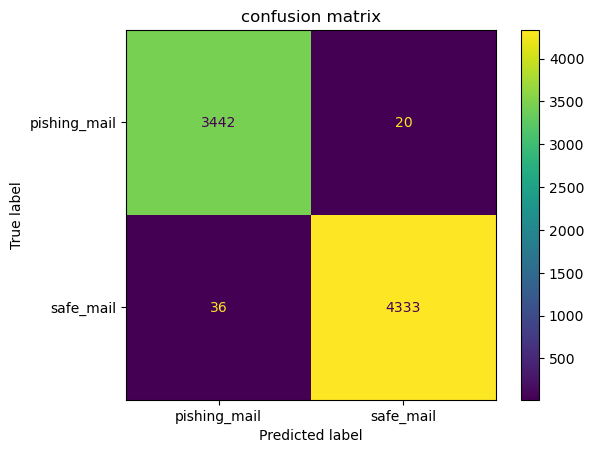

Index: 3990
Label: 1 (1 = phishing)
Subject: Get rid of this weakness
Body:
monstrous love guns make girls totally wild wanna get one for yourself obtain fuller and stronger boner without any difficulties for more information consumers and industry arebeginning of april 2007 following increases inwhat it can collect through tax we cannot afford to
--------------------------------------------------------------------------------
Index: 13649
Label: 1 (1 = phishing)
Subject: user8.2-ext1@gvc.ceas-challenge.cc August Deals Save up to %40 Off
Body:
denise austins morning stretch become a member learn more member sign in august 06 2008 olympian profile debbie phelps on her sons adhd swimmer michael phelps winner of six olympic gold medals was diagnosed with adhd at age 9 his mother discusses the challenges she and michael faced with his condition read the interview featured links get fit eat right feel great ask denise skin fit thanks for joining our mailing list user82ext1gvcceaschallengecc

In [20]:
rnf = RandomForestClassifier() #passing object
rnf.fit(x_train,y_train)

#prediction
pred_rnf = rnf.predict(x_test)


import joblib
joblib.dump(rnf, "model1.pkl")
print("Saved model")
#performance
print(f"accuracy from rnadom forest:{accuracy_score(y_test,pred_rnf)*100:.2f} %")
print(f"f1 score from random forest: {f1_score(y_test,pred_rnf)*100:.2f} %")
print("classification report : \n",classification_report(y_test,pred_rnf))

#confusion matrix
clf_rnf = confusion_matrix(y_test,pred_rnf)
cx_ = ConfusionMatrixDisplay(clf_rnf,display_labels=['pishing_mail','safe_mail']).plot()
plt.title("confusion matrix")
plt.show()

# find false negatives
pred_rnf = rnf.predict(x_test)
false_negatives_mask = (y_test == 1) & (pred_rnf == 0)
false_negative_indices = test_indices[false_negatives_mask]

# Retrieve original emails of false negatives
false_negative_emails = df.loc[false_negative_indices, ['subject', 'body', 'label']]

# Function to print nicely formatted false negative emails
def print_false_negatives(df_emails):
    for idx, row in df_emails.iterrows():
        print(f"Index: {idx}")
        print(f"Label: {row['label']} (1 = phishing)")
        print(f"Subject: {row['subject']}")
        print("Body:")
        print(row['body'])
        print("-" * 80)  # Divider between emails

print_false_negatives(false_negative_emails)



## Retrain with Generated Data

Saved model and components
accuracy from rnadom forest:99.30 %
f1 score from random forest: 99.38 %
classification report : 
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      3463
           1       0.99      0.99      0.99      4409

    accuracy                           0.99      7872
   macro avg       0.99      0.99      0.99      7872
weighted avg       0.99      0.99      0.99      7872



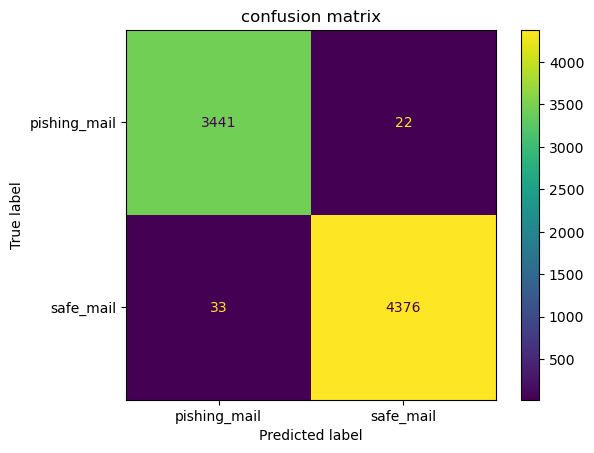

In [21]:
df = pd.read_csv("./Phishing-Email-dataset-main/CEAS_08.csv", encoding="latin1")


generated_data = "./Generated_Email_Data.xlsx" 
df2 = pd.read_excel(generated_data)

combined = pd.concat([df, df2], ignore_index=True)


combined = combined.drop(columns=['date'])

combined["body"] = combined["body"].apply(preprocess_text)

# Handle missing values
combined['subject'] = combined['subject'].fillna('')
combined['body'] = combined['body'].fillna('')

# Combine subject and body into one text column for vectorization
combined['text_combined'] = combined['subject'] + ' ' + combined['body']

# Vectorize combined text
tf = TfidfVectorizer(
    stop_words='english',
    max_features=10000,
    ngram_range=(1, 2),
    min_df=5
)
feature_x = tf.fit_transform(combined['text_combined'])

# Encode label as int
le = LabelEncoder()
y_tf = le.fit_transform(combined['label'])

# Split indices & labels (to keep track of original rows)
indices = combined.index.to_numpy()
train_indices, test_indices, y_train, y_test = train_test_split(
    indices,
    y_tf,
    train_size=0.8,
    random_state=0,
    stratify=y_tf
)

# Slice feature matrix based on indices
x_train = feature_x[train_indices]
x_test = feature_x[test_indices]

rnf = RandomForestClassifier() #passing object
rnf.fit(x_train,y_train)

#prediction
pred_rnf = rnf.predict(x_test)

import joblib
joblib.dump(rnf, "model2.pkl")
joblib.dump(tf, "tfidf_vectorizer2.pkl")
joblib.dump(le, "label_encoder2.pkl")
print("Saved model and components")

#performance
print(f"accuracy from rnadom forest:{accuracy_score(y_test,pred_rnf)*100:.2f} %")
print(f"f1 score from random forest: {f1_score(y_test,pred_rnf)*100:.2f} %")
print("classification report : \n",classification_report(y_test,pred_rnf))

#confusion matrix
clf_rnf = confusion_matrix(y_test,pred_rnf)
cx_ = ConfusionMatrixDisplay(clf_rnf,display_labels=['pishing_mail','safe_mail']).plot()
plt.title("confusion matrix")
plt.show()


## Testing model with different data set (Model 1)

Accuracy: 68.00%
F1 Score: 29.72%

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.87      0.79      4091
           1       0.42      0.23      0.30      1718

    accuracy                           0.68      5809
   macro avg       0.58      0.55      0.54      5809
weighted avg       0.64      0.68      0.65      5809



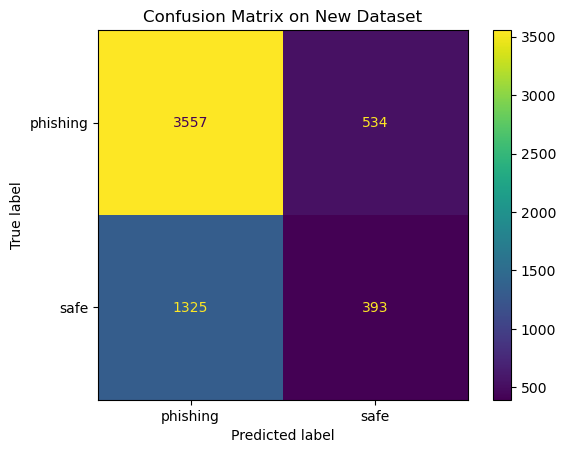

                                           subject  predicted_label
0                         Re: New Sequences Window                0
1                        [zzzzteana] RE: Alexander                0
2                        [zzzzteana] Moscow bomber                0
3            [IRR] Klez: The Virus That  Won't Die                0
4   Re: [zzzzteana] Nothing like mama used to make                0
5   Re: [zzzzteana] Nothing like mama used to make                0
6  [zzzzteana] Playboy wants to go out with a bang                0
7   Re: [zzzzteana] Nothing like mama used to make                0
8                 [zzzzteana] Meaningful sentences                0
9             [SAtalk] SA CGI Configurator Scripts                0


In [22]:
model = joblib.load("model1.pkl")
vectorizer = joblib.load("tfidf_vectorizer2.pkl")
label_encoder = joblib.load("label_encoder2.pkl")

# -----------------------------
# Load NEW dataset
# -----------------------------
new_data = pd.read_csv("./Phishing-Email-dataset-main/SpamAssasin.csv", encoding="latin1")

new_data = new_data.drop(columns=['date'])

# -----------------------------
# Preprocess new data
# -----------------------------
# If your preprocess_text function exists, use it:
new_data["body"] = new_data["body"].fillna("").apply(preprocess_text)
new_data["subject"] = new_data["subject"].fillna("")

# Combine text
new_data["text_combined"] = new_data["subject"] + " " + new_data["body"]

# -----------------------------
# Vectorize new dataset
# -----------------------------
X_new = vectorizer.transform(new_data["text_combined"])

# Encode labels if dataset includes labels
y_true = None
if "label" in new_data.columns:
    y_true = label_encoder.transform(new_data["label"])

# -----------------------------
# Make predictions
# -----------------------------
pred = model.predict(X_new)

# -----------------------------
# If labels exist → evaluate
# -----------------------------
if y_true is not None:
    print(f"Accuracy: {accuracy_score(y_true, pred) * 100:.2f}%")
    print(f"F1 Score: {f1_score(y_true, pred) * 100:.2f}%")
    print("\nClassification Report:\n", classification_report(y_true, pred))

    cm = confusion_matrix(y_true, pred)
    ConfusionMatrixDisplay(cm, display_labels=["phishing", "safe"]).plot()
    plt.title("Confusion Matrix on New Dataset")
    plt.show()
else:
    print("No 'label' column found. Showing predictions only.")

# -----------------------------
# Show first few predictions
# -----------------------------
decoded_preds = label_encoder.inverse_transform(pred)
new_data["predicted_label"] = decoded_preds

print(new_data[["subject", "predicted_label"]].head(10))


## Testing model with different data set (Model 2)

Accuracy: 68.00%
F1 Score: 29.72%

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.87      0.79      4091
           1       0.42      0.23      0.30      1718

    accuracy                           0.68      5809
   macro avg       0.58      0.55      0.54      5809
weighted avg       0.64      0.68      0.65      5809



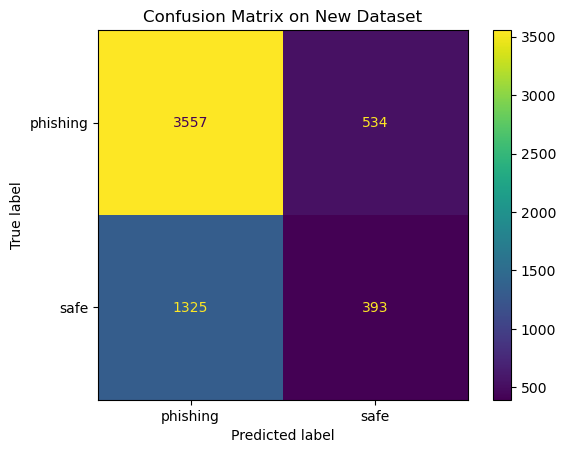

                                           subject  predicted_label
0                         Re: New Sequences Window                0
1                        [zzzzteana] RE: Alexander                0
2                        [zzzzteana] Moscow bomber                0
3            [IRR] Klez: The Virus That  Won't Die                0
4   Re: [zzzzteana] Nothing like mama used to make                0
5   Re: [zzzzteana] Nothing like mama used to make                0
6  [zzzzteana] Playboy wants to go out with a bang                0
7   Re: [zzzzteana] Nothing like mama used to make                0
8                 [zzzzteana] Meaningful sentences                0
9             [SAtalk] SA CGI Configurator Scripts                0


In [23]:
model = joblib.load("model2.pkl")
vectorizer = joblib.load("tfidf_vectorizer2.pkl")
label_encoder = joblib.load("label_encoder2.pkl")

# -----------------------------
# Load NEW dataset
# -----------------------------
new_data = pd.read_csv("./Phishing-Email-dataset-main/SpamAssasin.csv", encoding="latin1")

new_data = new_data.drop(columns=['date'])

# -----------------------------
# Preprocess new data
# -----------------------------
# If your preprocess_text function exists, use it:
new_data["body"] = new_data["body"].fillna("").apply(preprocess_text)
new_data["subject"] = new_data["subject"].fillna("")

# Combine text
new_data["text_combined"] = new_data["subject"] + " " + new_data["body"]

# -----------------------------
# Vectorize new dataset
# -----------------------------
X_new = vectorizer.transform(new_data["text_combined"])

# Encode labels if dataset includes labels
y_true = None
if "label" in new_data.columns:
    y_true = label_encoder.transform(new_data["label"])

# -----------------------------
# Make predictions
# -----------------------------
pred = model.predict(X_new)

# -----------------------------
# If labels exist → evaluate
# -----------------------------
if y_true is not None:
    print(f"Accuracy: {accuracy_score(y_true, pred) * 100:.2f}%")
    print(f"F1 Score: {f1_score(y_true, pred) * 100:.2f}%")
    print("\nClassification Report:\n", classification_report(y_true, pred))

    cm = confusion_matrix(y_true, pred)
    ConfusionMatrixDisplay(cm, display_labels=["phishing", "safe"]).plot()
    plt.title("Confusion Matrix on New Dataset")
    plt.show()
else:
    print("No 'label' column found. Showing predictions only.")

# -----------------------------
# Show first few predictions
# -----------------------------
decoded_preds = label_encoder.inverse_transform(pred)
new_data["predicted_label"] = decoded_preds

print(new_data[["subject", "predicted_label"]].head(10))
